In [10]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [6]:
PARTITIONS_CSV = "TestingData/partitions.csv"   # output of book_partitioner.ipynb

# Genres in a consistent display order
GENRES = ["biography", "fantasy", "horror", "romance", "sci-fi"]

In [7]:
partitions = pd.read_csv(PARTITIONS_CSV)

print(f"Partitions loaded : {len(partitions):,} rows")
print(f"\nGenre distribution:")
print(partitions['genre'].value_counts().to_string())
partitions.head(3)

Partitions loaded : 5,000 rows

Genre distribution:
genre
biography    1000
fantasy      1000
horror       1000
romance      1000
sci-fi       1000


,partition_id,book,genre,start_token,text,word_count
0,AutobiographyOfBenjaminFranklin_partition_a,AutobiographyOfBenjaminFranklin,biography,14592,Boston. I took leave of Keimer as going to see...,400
1,AutobiographyOfBenjaminFranklin_partition_b,AutobiographyOfBenjaminFranklin,biography,3278,translated into all the languages of Europe. I...,400
2,AutobiographyOfBenjaminFranklin_partition_c,AutobiographyOfBenjaminFranklin,biography,36048,"in conversation, which makes his company still...",400


New: BOW Added for feature engineering

In [11]:
X_text = partitions["text"].tolist()
y      = partitions["genre"].tolist()

# TF-IDF Vectorization
tfidf_vec = TfidfVectorizer(
    max_features=2000, 
    stop_words='english', 
    ngram_range=(1, 2)
)
tfidf_features = tfidf_vec.fit_transform(X_text)

# ── NEW: Raw BOW (term counts, no TF-IDF weighting)
bow_vec = CountVectorizer(
    max_features=2000,
    stop_words='english',
    ngram_range=(1, 2)
)
bow_features = bow_vec.fit_transform(X_text)


# LDA Features
count_vec = CountVectorizer(max_features=2000, stop_words='english')
raw_counts = count_vec.fit_transform(X_text)

lda_model = LatentDirichletAllocation(
    n_components=5,      # Since we have 5 genres, we look for 5 topics
    random_state=42,
    n_jobs=-1
)
lda_features = lda_model.fit_transform(raw_counts)

# Embeddings
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embedding_features = embedding_model.encode(X_text, show_progress_bar=True)


print(f"BOW shape: {bow_features.shape}")
print(f"TF-IDF shape: {tfidf_features.shape}")
print(f"LDA shape: {lda_features.shape}")
print(f"Embedding shape: {embedding_features.shape}")

Batches: 100%|██████████| 157/157 [00:25<00:00,  6.07it/s]

BOW shape: (5000, 2000)
TF-IDF shape: (5000, 2000)
LDA shape: (5000, 5)
Embedding shape: (5000, 384)


Clustering Grid (MODIFIED — adds BOW + Coherence)

In [21]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, cohen_kappa_score
import pandas as pd
from collections import Counter
from itertools import combinations


def map_clusters_to_labels(y_true, y_pred):
    """
    Maps cluster IDs to the most frequent genre label in that cluster.
    """
    # Convert y_true to a numpy array for easier indexing
    y_true_arr = np.array(y_true)
    
    mapping = {}
    unique_clusters = np.unique(y_pred)
    
    for cluster_id in unique_clusters:
        # Find all actual labels that ended up in this cluster
        mask = (y_pred == cluster_id)
        if sum(mask) == 0: continue
        
        # Get the subset of genre labels in this cluster
        genre_subset = y_true_arr[mask]
        
        # Use Counter instead of scipy.stats.mode
        # most_common(1) returns [(label, count)]
        most_frequent_label = Counter(genre_subset).most_common(1)[0][0]
        mapping[cluster_id] = most_frequent_label
    
    # Create the mapped predictions
    mapped_predictions = [mapping.get(p, "unknown") for p in y_pred]
    return mapped_predictions

#New: Coherence Helper

def get_top_words_per_cluster(X_input, labels, vectorizer, n_top=10):
    """For each cluster, return its top-n words by mean count/TF-IDF score."""
    topics = []
    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        mean_scores = np.asarray(X_input[mask].mean(axis=0)).flatten()
        top_idx = mean_scores.argsort()[-n_top:][::-1]
        topics.append([vectorizer.get_feature_names_out()[i] for i in top_idx])
    return topics

def compute_coherence(top_words_per_topic, doc_term_matrix, vectorizer, eps=1e-12):
    """Simplified C_V-style coherence: average PMI over word pairs in each topic's top words."""
    vocab = vectorizer.vocabulary_
    doc_term_binary = (doc_term_matrix > 0).astype(int)
    n_docs = doc_term_binary.shape[0]
    word_doc_freq = np.asarray(doc_term_binary.sum(axis=0)).flatten()

    topic_coherences = []
    for words in top_words_per_topic:
        word_indices = [vocab[w] for w in words if w in vocab]
        pair_scores = []
        for i, j in combinations(word_indices, 2):
            co_occur = doc_term_binary[:, i].multiply(doc_term_binary[:, j]).sum()
            p_i = word_doc_freq[i] / n_docs
            p_j = word_doc_freq[j] / n_docs
            p_ij = co_occur / n_docs
            pmi = np.log((p_ij + eps) / (p_i * p_j + eps))
            pair_scores.append(pmi)
        topic_coherences.append(np.mean(pair_scores) if pair_scores else 0)

    return np.mean(topic_coherences)

# 2. Setup Models and Features
feature_sets = {
    "BOW": bow_features,
    "TF-IDF": tfidf_features,
    "LDA": lda_features,
    "Embeddings": embedding_features
}

# Only BOW and TF-IDF have a vectorizer with interpretable vocabulary words
coherence_vectorizers = {
    "BOW": (bow_vec, bow_features),
    "TF-IDF": (tfidf_vec, tfidf_features),
}

models = {
    "K-Means": KMeans(n_clusters=5, random_state=42),
    "EM (GMM)": GaussianMixture(n_components=5, random_state=42),
    "Hierarchical": AgglomerativeClustering(n_clusters=5)
}

# 3. Run Pipeline
results = []

for feature_name, X in feature_sets.items():
    for model_name, model in models.items():
        print(f"Running {model_name} on {feature_name}...")
        
        # Fit model
        X_input = X.toarray() if hasattr(X, "toarray") else X
        
        # Fit model using the new X_input
        # (We use the same logic for all, since we converted X to dense)
        labels = model.fit_predict(X_input)
            
        # Evaluation
        sil_score = silhouette_score(X_input, labels)
        
        # Map labels to genres for Kappa calculation
        mapped_labels = map_clusters_to_labels(y, labels)
        kappa = cohen_kappa_score(y, mapped_labels)
         # ── NEW: Coherence (only for BOW/TF-IDF, where vocab words are interpretable) ──
        if feature_name in coherence_vectorizers:
            vec, raw_matrix = coherence_vectorizers[feature_name]
            topics = get_top_words_per_cluster(X, labels, vec)
            coherence = compute_coherence(topics, raw_matrix, vec)
        else:
            coherence = np.nan
        # ───────────────────────────────────────────────
        results.append({
            "Feature": feature_name,
            "Algorithm": model_name,
            "Silhouette": sil_score,
            "Kappa": kappa,
            "Coherence": coherence
        })

# 4. Display Results
results_df = pd.DataFrame(results)
print(results_df.to_string())

# ── NEW: LDA native topic coherence (separate from cluster-derived topics) ──
lda_topics = []
for topic_idx in range(lda_model.n_components):
    top_idx = lda_model.components_[topic_idx].argsort()[-10:][::-1]
    lda_topics.append([count_vec.get_feature_names_out()[i] for i in top_idx])

lda_native_coherence = compute_coherence(lda_topics, raw_counts, count_vec)
print(f"\nLDA native topic coherence (separate from cluster topics): {lda_native_coherence:.4f}")
# ──────────────────────────────────────────────────────────────────────────────

Running K-Means on BOW...
Running EM (GMM) on BOW...
Running Hierarchical on BOW...
Running K-Means on TF-IDF...
Running EM (GMM) on TF-IDF...
Running Hierarchical on TF-IDF...
Running K-Means on LDA...
Running EM (GMM) on LDA...
Running Hierarchical on LDA...
Running K-Means on Embeddings...
Running EM (GMM) on Embeddings...
Running Hierarchical on Embeddings...
       Feature     Algorithm  Silhouette    Kappa  Coherence
0          BOW       K-Means    0.050658  0.24325   0.797806
1          BOW      EM (GMM)    0.050658  0.24325   0.797806
2          BOW  Hierarchical    0.077783  0.28900   0.833325
3       TF-IDF       K-Means    0.020640  0.32300  -1.165958
4       TF-IDF      EM (GMM)    0.020640  0.32300  -1.165958
5       TF-IDF  Hierarchical    0.025156  0.24775   1.648898
6          LDA       K-Means    0.552350  0.44900        NaN
7          LDA      EM (GMM)    0.134632  0.26725        NaN
8          LDA  Hierarchical    0.516704  0.45750        NaN
9   Embeddings       K-M

Visualizations (Modified - add Coherence chart)

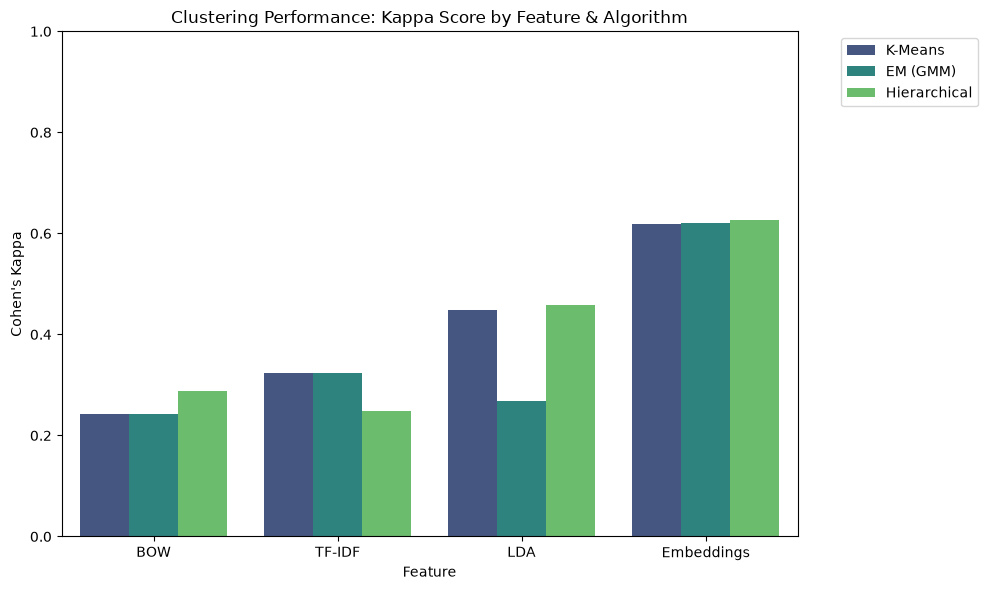

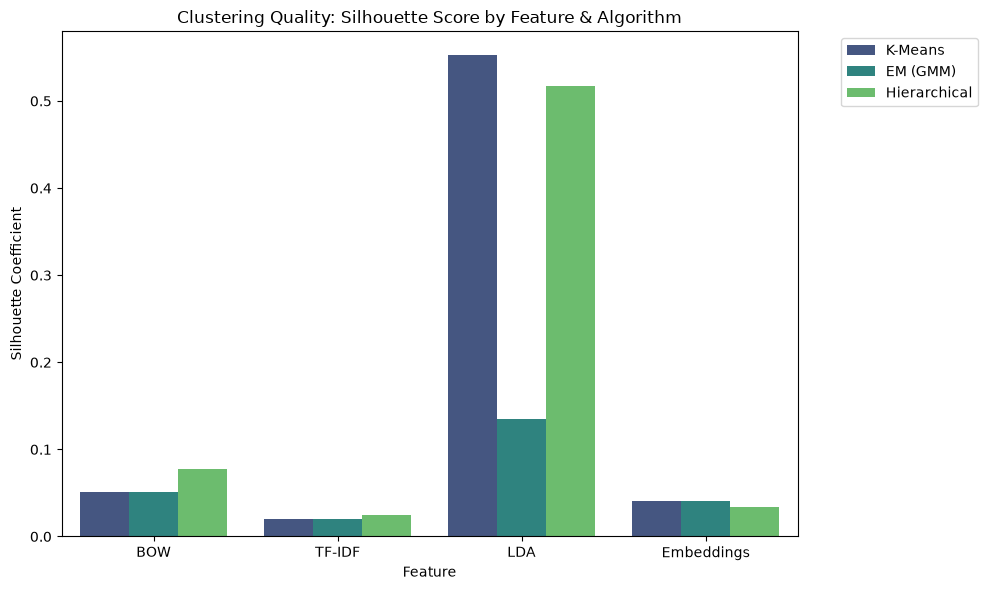

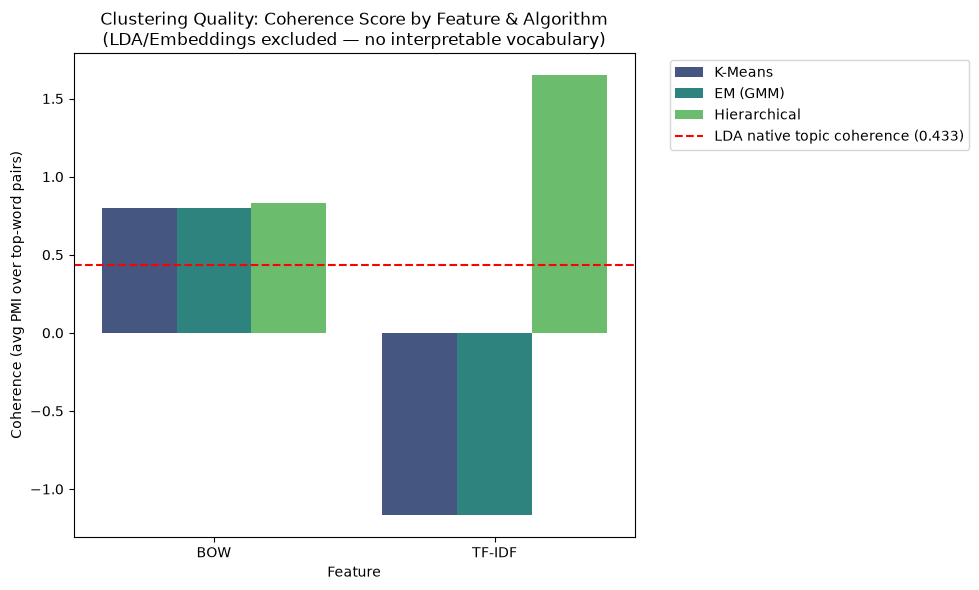

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Visualization: Kappa Score Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Feature", y="Kappa", hue="Algorithm", palette="viridis")
plt.title("Clustering Performance: Kappa Score by Feature & Algorithm")
plt.ylabel("Cohen's Kappa")
plt.ylim(0, 1) # Kappa is 0 to 1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Visualization: Silhouette Score Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Feature", y="Silhouette", hue="Algorithm", palette="viridis")
plt.title("Clustering Quality: Silhouette Score by Feature & Algorithm")
plt.ylabel("Silhouette Coefficient")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ── NEW: 3. Visualization: Coherence Score Comparison (BOW & TF-IDF only) ──
coherence_df = results_df.dropna(subset=["Coherence"])
plt.figure(figsize=(10, 6))
sns.barplot(data=coherence_df, x="Feature", y="Coherence", hue="Algorithm", palette="viridis")
plt.title("Clustering Quality: Coherence Score by Feature & Algorithm\n(LDA/Embeddings excluded — no interpretable vocabulary)")
plt.ylabel("Coherence (avg PMI over top-word pairs)")
plt.axhline(y=lda_native_coherence, color='red', linestyle='--',
            label=f'LDA native topic coherence ({lda_native_coherence:.3f})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Error Analysis Function (modified - add collocations)

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)
STOP = set(stopwords.words('english'))


# ── NEW: collocation helper ──────────────────────────────────────────────────
def top_collocations(texts, n=10, freq_filter=3):
    """Return top-n bigram collocations by PMI from a list of text strings."""
    tokens = []
    for t in texts:
        words = [w for w in t.lower().split() if w.isalpha() and w not in STOP]
        tokens.extend(words)
    finder = BigramCollocationFinder.from_words(tokens)
    finder.apply_freq_filter(freq_filter)
    return finder.nbest(BigramAssocMeasures.pmi, n)
# ──────────────────────────────────────────────────────────────────────────────

def analyze_errors(X_text, y_true, y_pred, samples_per_genre=2):
    """
    Identifies misclassified samples, extracts characteristics, 
    and prints actual text examples for manual review.
    """
    error_df = pd.DataFrame({"text": X_text, "true": y_true, "predicted": y_pred})
    errors = error_df[error_df['true'] != error_df['predicted']]
    
    print(f"Total Errors Found: {len(errors)}")
    
    # --- Print sample text examples ---
    print(f"\n--- Reviewing {samples_per_genre} Sample Misclassifications Per Genre ---")
    
    for genre in errors['true'].unique():
        genre_errors = errors[errors['true'] == genre]
        
        # Take a sample, or all if less than N
        n = min(samples_per_genre, len(genre_errors))
        sample_subset = genre_errors.sample(n=n, random_state=42)
        
        print(f"\n[Genre: {genre}]")
        for i, row in sample_subset.iterrows():
            print(f"  Predicted: {row['predicted']}")
            print(f"  Snippet: {row['text'][:150]}...")
    
    # --- Existing: Top Characteristics ---
    vec = CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=10)
    error_matrix = vec.fit_transform(errors["text"])
    
    print("\n--- Top 10 Characteristics of Misclassified Instances ---")
    for feature in vec.get_feature_names_out():
        print(f"- {feature}")
         # ── NEW: top collocations (PMI-based) ──
    print("\n--- Top 10 Collocations in Misclassified Instances (by PMI) ---")
    for w1, w2 in top_collocations(errors["text"].tolist()):
        print(f"- {w1} {w2}")
    # ────────────────────────────────────────
    return errors

Champoin Model + Error Analysis

--- CHAMPION MODEL ---
Algorithm: Hierarchical
Feature: Embeddings
Kappa: 0.6273


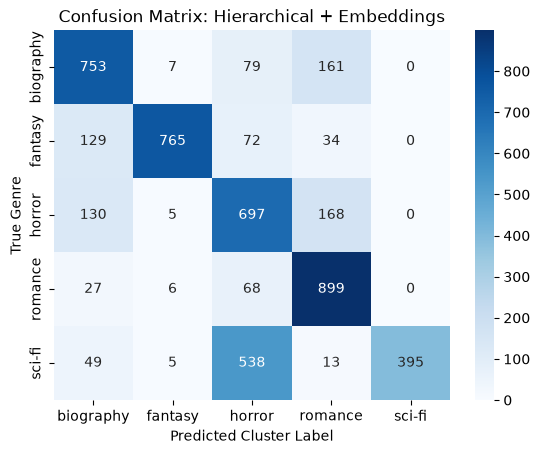

Total Errors Found: 1491

--- Reviewing 2 Sample Misclassifications Per Genre ---

[Genre: biography]
  Predicted: romance
  Snippet: having seen any authentic record containing it. By far the larger part of the slaves know as little of their ages as horses know of theirs, and it is ...
  Predicted: horror
  Snippet: fighting. Their dark-colour'd bodies, half naked, seen only by the gloomy light of the bonfire, running after and beating one another with firebrands,...

[Genre: fantasy]
  Predicted: biography
  Snippet: A continuation of the state of England under Queen Anne. The character of a first minister of state in European courts. My master was yet wholly at a ...
  Predicted: horror
  Snippet: full of meat, which had been provided and sent thither by the king’s orders, upon the first intelligence he received of me. I observed there was the f...

[Genre: horror]
  Predicted: romance
  Snippet: to do with this so terrible affair. It is not good that she run a risk so great. We men

In [27]:
from sklearn.metrics import confusion_matrix

# 1. Find the best model (The Champion)
best_model_idx = results_df['Kappa'].idxmax()
best_model_row = results_df.loc[best_model_idx]

print(f"--- CHAMPION MODEL ---")
print(f"Algorithm: {best_model_row['Algorithm']}")
print(f"Feature: {best_model_row['Feature']}")
print(f"Kappa: {best_model_row['Kappa']:.4f}")

# 2. Re-run that specific model to get the labels again
# (You might need to re-fit or store your predictions during the loop)
# For simplicity, if you didn't store all predictions, you can re-fit:
best_model = models[best_model_row['Algorithm']]
X_best = feature_sets[best_model_row['Feature']]
X_input = X_best.toarray() if hasattr(X_best, "toarray") else X_best

labels_best = best_model.fit_predict(X_input)
mapped_best = map_clusters_to_labels(y, labels_best)

# 3. Create Confusion Matrix for the Champion
cm = confusion_matrix(y, mapped_best, labels=GENRES)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=GENRES, yticklabels=GENRES)
plt.title(f"Confusion Matrix: {best_model_row['Algorithm']} + {best_model_row['Feature']}")
plt.xlabel("Predicted Cluster Label")
plt.ylabel("True Genre")
plt.show()

# 4. Error Analysis for the Champion
misclassified_df = analyze_errors(X_text, y, mapped_best)

New: Cosine-Distance Hierarchical

In [25]:

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, cohen_kappa_score

cosine_hier = AgglomerativeClustering(n_clusters=5, metric='cosine', linkage='average')
labels_cosine = cosine_hier.fit_predict(embedding_features)

sil_cosine = silhouette_score(embedding_features, labels_cosine, metric='cosine')
mapped_cosine = map_clusters_to_labels(y, labels_cosine)
kappa_cosine = cohen_kappa_score(y, mapped_cosine)

print(f"Hierarchical (cosine, average linkage) on Embeddings")
print(f"  Silhouette (cosine): {sil_cosine:.4f}")
print(f"  Kappa: {kappa_cosine:.4f}")

# Compare against original Euclidean/Ward result for the same feature+algorithm
original_row = results_df[
    (results_df["Feature"] == "Embeddings") & (results_df["Algorithm"] == "Hierarchical")
]
print(f"\nFor comparison — Hierarchical (Euclidean/Ward) on Embeddings:")
print(original_row[["Silhouette", "Kappa"]].to_string(index=False))

Hierarchical (cosine, average linkage) on Embeddings
  Silhouette (cosine): 0.0970
  Kappa: 0.0028

For comparison — Hierarchical (Euclidean/Ward) on Embeddings:
 Silhouette   Kappa
    0.03352 0.62725


New: Per Genre Purity Breakdown

Per-genre purity for champion (Hierarchical + Embeddings):
    Genre  Purity
biography   0.753
  fantasy   0.765
   horror   0.697
  romance   0.899
   sci-fi   0.395


/var/folders/h4/hbx24v5x5n32kykbtbv526dm0000gn/T/ipykernel_93598/2870310500.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=purity_df, x="Genre", y="Purity", palette="viridis")


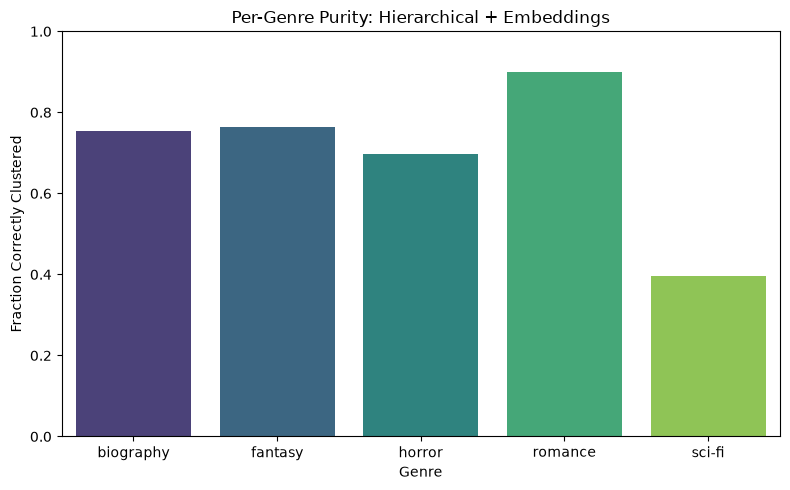

In [28]:

def per_genre_purity(y_true, mapped_pred, genres):
    y_true_arr = np.array(y_true)
    mapped_arr = np.array(mapped_pred)
    purity = {}
    for genre in genres:
        mask = y_true_arr == genre
        purity[genre] = (mapped_arr[mask] == genre).mean()
    return purity

# Uses 'mapped_best' and 'best_model_row' from Cell 7 (champion model)
genre_purity = per_genre_purity(y, mapped_best, GENRES)

purity_df = pd.DataFrame({
    "Genre": list(genre_purity.keys()),
    "Purity": list(genre_purity.values())
})

print(f"Per-genre purity for champion ({best_model_row['Algorithm']} + {best_model_row['Feature']}):")
print(purity_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=purity_df, x="Genre", y="Purity", palette="viridis")
plt.title(f"Per-Genre Purity: {best_model_row['Algorithm']} + {best_model_row['Feature']}")
plt.ylabel("Fraction Correctly Clustered")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

New: Seed Stability Check - Stability across random seeds (K-Means and GMM only)

In [29]:

def run_with_seeds(model_class, model_kwargs, X_input, y, n_seeds=5):
    kappas, sils = [], []
    for seed in range(n_seeds):
        kwargs = {**model_kwargs, 'random_state': seed}
        model = model_class(**kwargs)
        labels = model.fit_predict(X_input)
        sils.append(silhouette_score(X_input, labels))
        mapped = map_clusters_to_labels(y, labels)
        kappas.append(cohen_kappa_score(y, mapped))
    return np.mean(kappas), np.std(kappas), np.mean(sils), np.std(sils)


stability_results = []
for feature_name, X in feature_sets.items():
    X_input = X.toarray() if hasattr(X, "toarray") else X

    k_mean, k_std, s_mean, s_std = run_with_seeds(
        KMeans, {"n_clusters": 5}, X_input, y
    )
    stability_results.append({
        "Feature": feature_name, "Algorithm": "K-Means",
        "Kappa_mean": k_mean, "Kappa_std": k_std,
        "Silhouette_mean": s_mean, "Silhouette_std": s_std
    })

    g_mean, g_std, gs_mean, gs_std = run_with_seeds(
        GaussianMixture, {"n_components": 5}, X_input, y
    )
    stability_results.append({
        "Feature": feature_name, "Algorithm": "EM (GMM)",
        "Kappa_mean": g_mean, "Kappa_std": g_std,
        "Silhouette_mean": gs_mean, "Silhouette_std": gs_std
    })

stability_df = pd.DataFrame(stability_results)
print("Stability across 5 random seeds (Hierarchical excluded — deterministic):")
print(stability_df.to_string(index=False))

Stability across 5 random seeds (Hierarchical excluded — deterministic):
   Feature Algorithm  Kappa_mean  Kappa_std  Silhouette_mean  Silhouette_std
       BOW   K-Means     0.27375   0.053195         0.040346        0.030113
       BOW  EM (GMM)     0.27375   0.053195         0.040346        0.030113
    TF-IDF   K-Means     0.38920   0.054294         0.021094        0.001424
    TF-IDF  EM (GMM)     0.38920   0.054294         0.021094        0.001424
       LDA   K-Means     0.44900   0.000000         0.552356        0.000011
       LDA  EM (GMM)     0.28725   0.010500         0.172111        0.018842
Embeddings   K-Means     0.53030   0.069238         0.038969        0.002860
Embeddings  EM (GMM)     0.53085   0.069517         0.038947        0.002844
